In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x = np.linspace(-5.0,5.0,100)
y = np.sqrt(10**2 - x**2)
y = np.hstack([y,-y])
x = np.hstack([x,-x])

In [2]:
x1 = np.linspace(-5.0,5.0,100)
y1 = np.sqrt(5**2 - x1**2)
y1 = np.hstack([y1,-y1])
x1 = np.hstack([x1,-x1])


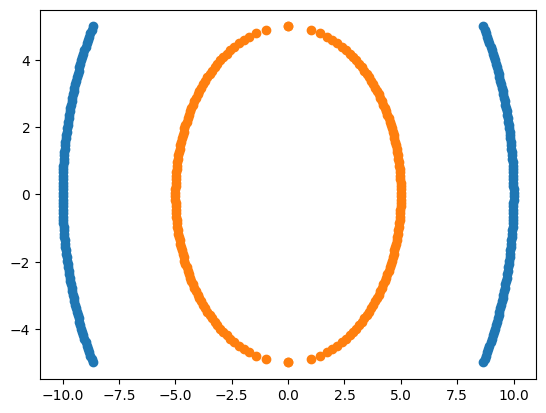

In [3]:
plt.scatter(y,x)
plt.scatter(y1,x1)

In [4]:
import pandas as pd

df1=pd.DataFrame(np.vstack([y,x]).T,columns=['X1','X2'])
df1['Y']=0
df2=pd.DataFrame(np.vstack([y1,x1]).T,columns=['X1','X2'])
df2['Y']=1
df = pd.concat([df1, df2], ignore_index=True)
df.head(5)

,X1,X2,Y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0


In [5]:
df.tail()

,X1,X2,Y
395,-1.969049,-4.59596,1
396,-1.714198,-4.69697,1
397,-1.406908,-4.79798,1
398,-0.999949,-4.89899,1
399,-0.000000,-5.00000,1


In [5]:
#Independent and Dependent features
X = df.iloc[:,:2]
y = df.Y

In [7]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    1
399    1
Name: Y, Length: 400, dtype: int64

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=10)

In [9]:
y_train

57     0
87     0
357    1
355    1
238    1
      ..
369    1
320    1
15     0
125    0
265    1
Name: Y, Length: 300, dtype: int64

In [7]:
df['X1_Square'] = df['X1']**2
df['X2_Square'] = df['X1']**2
df['X1*X2'] = (df['X1'] * df['X2'])
df.head()

,X1,X2,Y,X1_Square,X2_Square,X1*X2
0,8.660254,-5.00000,0,75.000000,75.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,75.999898,-42.708375
2,8.773790,-4.79798,0,76.979390,76.979390,-42.096467
3,8.828277,-4.69697,0,77.938476,77.938476,-41.466150
4,8.881281,-4.59596,0,78.877155,78.877155,-40.818009


In [8]:
#Independenet and Depenedent features
X = df[['X1','X2','X1_Square','X2_Square','X1*X2']]
y = df['Y']

In [12]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    1
399    1
Name: Y, Length: 400, dtype: int64

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=10)

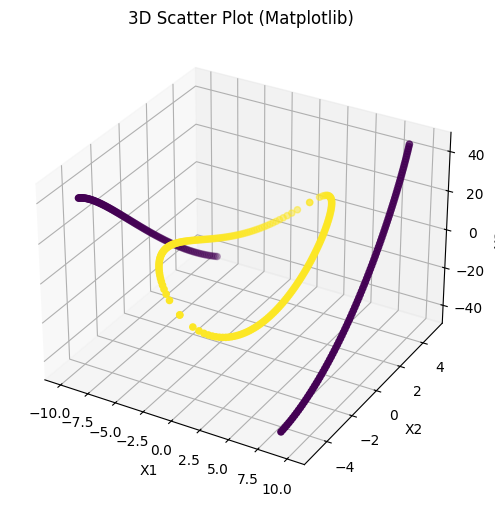

In [11]:
# import plotly.express as px

# fig = px.scatter_3d(df,x='X1',y='X2',z='X1*X2',color='Y')

# fig.show()

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Assuming your DataFrame is `df` with columns 'X1', 'X2', 'Y'
# Compute X1*X2 on the fly
ax.scatter(df['X1'], df['X2'], df['X1'] * df['X2'], c=df['Y'], cmap='viridis')

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X1 * X2')
plt.title('3D Scatter Plot (Matplotlib)')
plt.show()

In [14]:
import plotly.express as px

fig = px.scatter_3d(df,x='X1',y='X2',z='X1*X2',color='Y')

fig.show()

In [16]:
fig = px.scatter_3d(df,'X1_Square',y='X1_Square',z='X1*X2',color='Y')

fig.show()

In [17]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel='linear')
classifier.fit(X_train,y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test,y_pred)

1.0

In [18]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel='poly')
classifier.fit(X_train,y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test,y_pred)

1.0

In [20]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel='rbf')
classifier.fit(X_train,y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test,y_pred)

1.0